In [179]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import gc
from google.colab import drive
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, LinearSVC
import joblib

In [180]:


# 1. Mount Drive (if not already mounted)
drive.mount('/content/drive')

path = '/content/drive/MyDrive/archive/*.csv'
all_files = glob.glob(path)

full_data_list = []
# Columns we want to remove immediately to prevent numeric conversion errors
cols_to_drop = ['Timestamp', 'Flow ID', 'Src IP', 'Dst IP', 'Source IP', 'Destination IP']

print("Starting Robust Loading...")

for filename in all_files:
    # Optional: Skip the massive 4GB file to save RAM as discussed
    if '02-20-2018' in filename:
        print(f"Skipping 4GB test file: {filename}")
        continue

    print(f"Processing: {filename}")

    # Load 100k rows to be safe with RAM
    df_temp = pd.read_csv(filename, nrows=300000)

    # --- STEP 1: DROP REPEATED HEADERS ---
    # In this dataset, repeated headers have the word 'Label' in the 'Label' column
    if 'Label' in df_temp.columns:
        df_temp = df_temp[df_temp['Label'] != 'Label']

    # --- STEP 2: DROP TEXT COLUMNS ---
    existing_drops = [c for c in cols_to_drop if c in df_temp.columns]
    df_temp.drop(columns=existing_drops, inplace=True)

    # --- STEP 3: FORCE NUMERIC ---
    # Convert everything except 'Label' to float32
    for col in df_temp.columns:
        if col != 'Label':
            df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')

    # --- STEP 4: CLEAN INF/NAN ---
    df_temp.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_temp.dropna(inplace=True)

    # --- STEP 5: DOWNCAST ---
    for col in df_temp.select_dtypes(include=['float64']).columns:
        df_temp[col] = df_temp[col].astype('float32')
    for col in df_temp.select_dtypes(include=['int64']).columns:
        df_temp[col] = df_temp[col].astype('int32')

    full_data_list.append(df_temp)
    gc.collect()

# Final Concatenation
data = pd.concat(full_data_list, axis=0, ignore_index=True)
del full_data_list
gc.collect()

print(f"\nSuccess! Final stable row count: {len(data)}")
print(data.info())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Starting Robust Loading...
Processing: /content/drive/MyDrive/archive/02-14-2018.csv
Processing: /content/drive/MyDrive/archive/02-15-2018.csv
Processing: /content/drive/MyDrive/archive/02-16-2018.csv
Processing: /content/drive/MyDrive/archive/02-21-2018.csv
Processing: /content/drive/MyDrive/archive/02-22-2018.csv
Processing: /content/drive/MyDrive/archive/02-23-2018.csv
Processing: /content/drive/MyDrive/archive/02-28-2018.csv


/tmp/ipykernel_4418/2418802325.py:22: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(filename, nrows=300000)


Processing: /content/drive/MyDrive/archive/03-01-2018.csv


/tmp/ipykernel_4418/2418802325.py:22: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(filename, nrows=300000)


Processing: /content/drive/MyDrive/archive/03-02-2018.csv

Success! Final stable row count: 2688308
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2688308 entries, 0 to 2688307
Data columns (total 79 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Dst Port           int32  
 1   Protocol           int32  
 2   Flow Duration      int32  
 3   Tot Fwd Pkts       int32  
 4   Tot Bwd Pkts       int32  
 5   TotLen Fwd Pkts    int32  
 6   TotLen Bwd Pkts    float64
 7   Fwd Pkt Len Max    int32  
 8   Fwd Pkt Len Min    int32  
 9   Fwd Pkt Len Mean   float32
 10  Fwd Pkt Len Std    float32
 11  Bwd Pkt Len Max    int32  
 12  Bwd Pkt Len Min    int32  
 13  Bwd Pkt Len Mean   float32
 14  Bwd Pkt Len Std    float32
 15  Flow Byts/s        float32
 16  Flow Pkts/s        float32
 17  Flow IAT Mean      float32
 18  Flow IAT Std       float32
 19  Flow IAT Max       float64
 20  Flow IAT Min       float64
 21  Fwd IAT Tot        float64
 22  Fwd IAT Mean  

In [181]:
data.head()

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,112641719,3,0,0,0.0,0,0,0.000000,...,0,0.0,0.0,0.0,0.0,56320860.0,139.300034,56320958.0,56320761.0,Benign
1,0,0,112641466,3,0,0,0.0,0,0,0.000000,...,0,0.0,0.0,0.0,0.0,56320732.0,114.551300,56320814.0,56320652.0,Benign
2,0,0,112638623,3,0,0,0.0,0,0,0.000000,...,0,0.0,0.0,0.0,0.0,56319312.0,301.934601,56319525.0,56319098.0,Benign
3,22,6,6453966,15,10,1239,2273.0,744,0,82.599998,...,32,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
4,22,6,8804066,14,11,1143,2209.0,744,0,81.642860,...,32,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign


In [182]:
data['Label'].value_counts()

,count
Label,
Benign,1495326
DDOS attack-HOIC,296042
Bot,242500
FTP-BruteForce,179239
SSH-Bruteforce,119961
DoS attacks-Hulk,116247
Infilteration,92403
DoS attacks-SlowHTTPTest,91434
DoS attacks-GoldenEye,41508


In [183]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Dst Port,2688308.0,6.951006e+03,1.575753e+04,0.000000e+00,53.0,80.0,3389.00,6.553500e+04
Protocol,2688308.0,7.891211e+00,4.277317e+00,0.000000e+00,6.0,6.0,6.00,1.700000e+01
Flow Duration,2688308.0,9.900275e+06,2.853946e+07,-2.101873e+09,309.0,10632.0,1364032.75,1.553150e+09
Tot Fwd Pkts,2688308.0,8.055498e+01,3.062440e+03,1.000000e+00,1.0,2.0,4.00,3.096290e+05
Tot Bwd Pkts,2688308.0,5.409453e+00,1.401332e+02,0.000000e+00,0.0,1.0,4.00,5.321700e+04
...,...,...,...,...,...,...,...,...
Active Min,2688308.0,9.179995e+04,1.686475e+06,0.000000e+00,0.0,0.0,0.00,1.140000e+08
Idle Mean,2688308.0,5.057416e+06,5.503739e+08,0.000000e+00,0.0,0.0,0.00,3.955714e+11
Idle Std,2688308.0,7.264951e+05,3.404599e+08,0.000000e+00,0.0,0.0,0.00,2.622479e+11
Idle Max,2688308.0,4.297274e+06,1.599962e+07,-1.610514e+09,0.0,0.0,0.00,2.066358e+09


In [184]:
data.duplicated().sum()

np.int64(856348)

In [185]:
data.drop_duplicates(inplace=True)

In [186]:
data['Label'].value_counts()

,count
Label,
Benign,1272827
DDOS attack-HOIC,177655
Bot,122613
Infilteration,82531
SSH-Bruteforce,67204
DoS attacks-Hulk,55113
DoS attacks-GoldenEye,41406
DoS attacks-Slowloris,9908
DDOS attack-LOIC-UDP,1730


In [187]:
data['Label'] = data['Label'].astype(str).str.strip()

In [188]:
# 1. Define the Mapping Dictionary
attack_groups = {
    'Benign': 'Benign',
    'FTP-BruteForce': 'Brute Force',
    'SSH-Bruteforce': 'Brute Force',
    'Brute Force -Web': 'Web Attack',
    'Brute Force -XSS': 'Web Attack',
    'SQL Injection': 'Web Attack',
    'DoS attacks-GoldenEye': 'DoS',
    'DoS attacks-Slowloris': 'DoS',
    'DoS attacks-SlowHTTPTest': 'DoS',
    'DoS attacks-Hulk': 'DoS',
    'DDOS attack-HOIC': 'DDoS',
    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'DDOS attack-LOIC-UDP': 'DDoS',
    'Infiltration': 'Infiltration',
    'Bot': 'Bot'
}


In [189]:
data['Label'] = data['Label'].map(attack_groups)

In [190]:
failed_rows = data[data['Label'].isna()]
if len(failed_rows) > 0:
    print(f"Warning: {len(failed_rows)} rows failed mapping. Dropping them now.")
    data.dropna(subset=['Label'], inplace=True)

In [191]:
data['Label'].unique()

array(['Benign', 'Brute Force', 'DoS', 'DDoS', 'Web Attack', 'Bot'],
      dtype=object)

In [192]:
# Check the original counts before mapping
print("Current unique labels in data:")
print(data['Label'].value_counts())

Current unique labels in data:
Label
Benign         1272827
DDoS            179385
Bot             122613
DoS             106482
Brute Force      67257
Web Attack         865
Name: count, dtype: int64


In [193]:
print("Grouped Label Counts:\n", data['Label'].value_counts())

Grouped Label Counts:
 Label
Benign         1272827
DDoS            179385
Bot             122613
DoS             106482
Brute Force      67257
Web Attack         865
Name: count, dtype: int64


# balancing the data

In [194]:
df_benign = data[data['Label'] == 'Benign']
df_others = data[data['Label'] != 'Benign']

In [195]:
df_benign_sampled = resample(df_benign,
                             replace=False,
                             n_samples=183265,
                             random_state=42)

In [196]:
data_balanced = pd.concat([df_benign_sampled, df_others])

In [197]:
data_balanced['Label'].value_counts()

,count
Label,
Benign,183265
DDoS,179385
Bot,122613
DoS,106482
Brute Force,67257
Web Attack,865


In [198]:
data_balanced.reset_index(inplace=True,drop=True)

In [199]:
data_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 659867 entries, 0 to 659866
Data columns (total 79 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Dst Port           659867 non-null  int32  
 1   Protocol           659867 non-null  int32  
 2   Flow Duration      659867 non-null  int32  
 3   Tot Fwd Pkts       659867 non-null  int32  
 4   Tot Bwd Pkts       659867 non-null  int32  
 5   TotLen Fwd Pkts    659867 non-null  int32  
 6   TotLen Bwd Pkts    659867 non-null  float64
 7   Fwd Pkt Len Max    659867 non-null  int32  
 8   Fwd Pkt Len Min    659867 non-null  int32  
 9   Fwd Pkt Len Mean   659867 non-null  float32
 10  Fwd Pkt Len Std    659867 non-null  float32
 11  Bwd Pkt Len Max    659867 non-null  int32  
 12  Bwd Pkt Len Min    659867 non-null  int32  
 13  Bwd Pkt Len Mean   659867 non-null  float32
 14  Bwd Pkt Len Std    659867 non-null  float32
 15  Flow Byts/s        659867 non-null  float32
 16  Fl

In [200]:
le = LabelEncoder()
data_balanced['Label'] = le.fit_transform(data_balanced['Label'])
print("\nFinal 6 Classes:")
for i, name in enumerate(le.classes_):
    print(f"Value {i} -> {name}")


Final 6 Classes:
Value 0 -> Benign
Value 1 -> Bot
Value 2 -> Brute Force
Value 3 -> DDoS
Value 4 -> DoS
Value 5 -> Web Attack


Find the correlation and feature selection

In [201]:
corr_matrix = data_balanced.sample(50000).drop(columns=['Label', 'Grouped_Label'], errors='ignore').corr().abs()

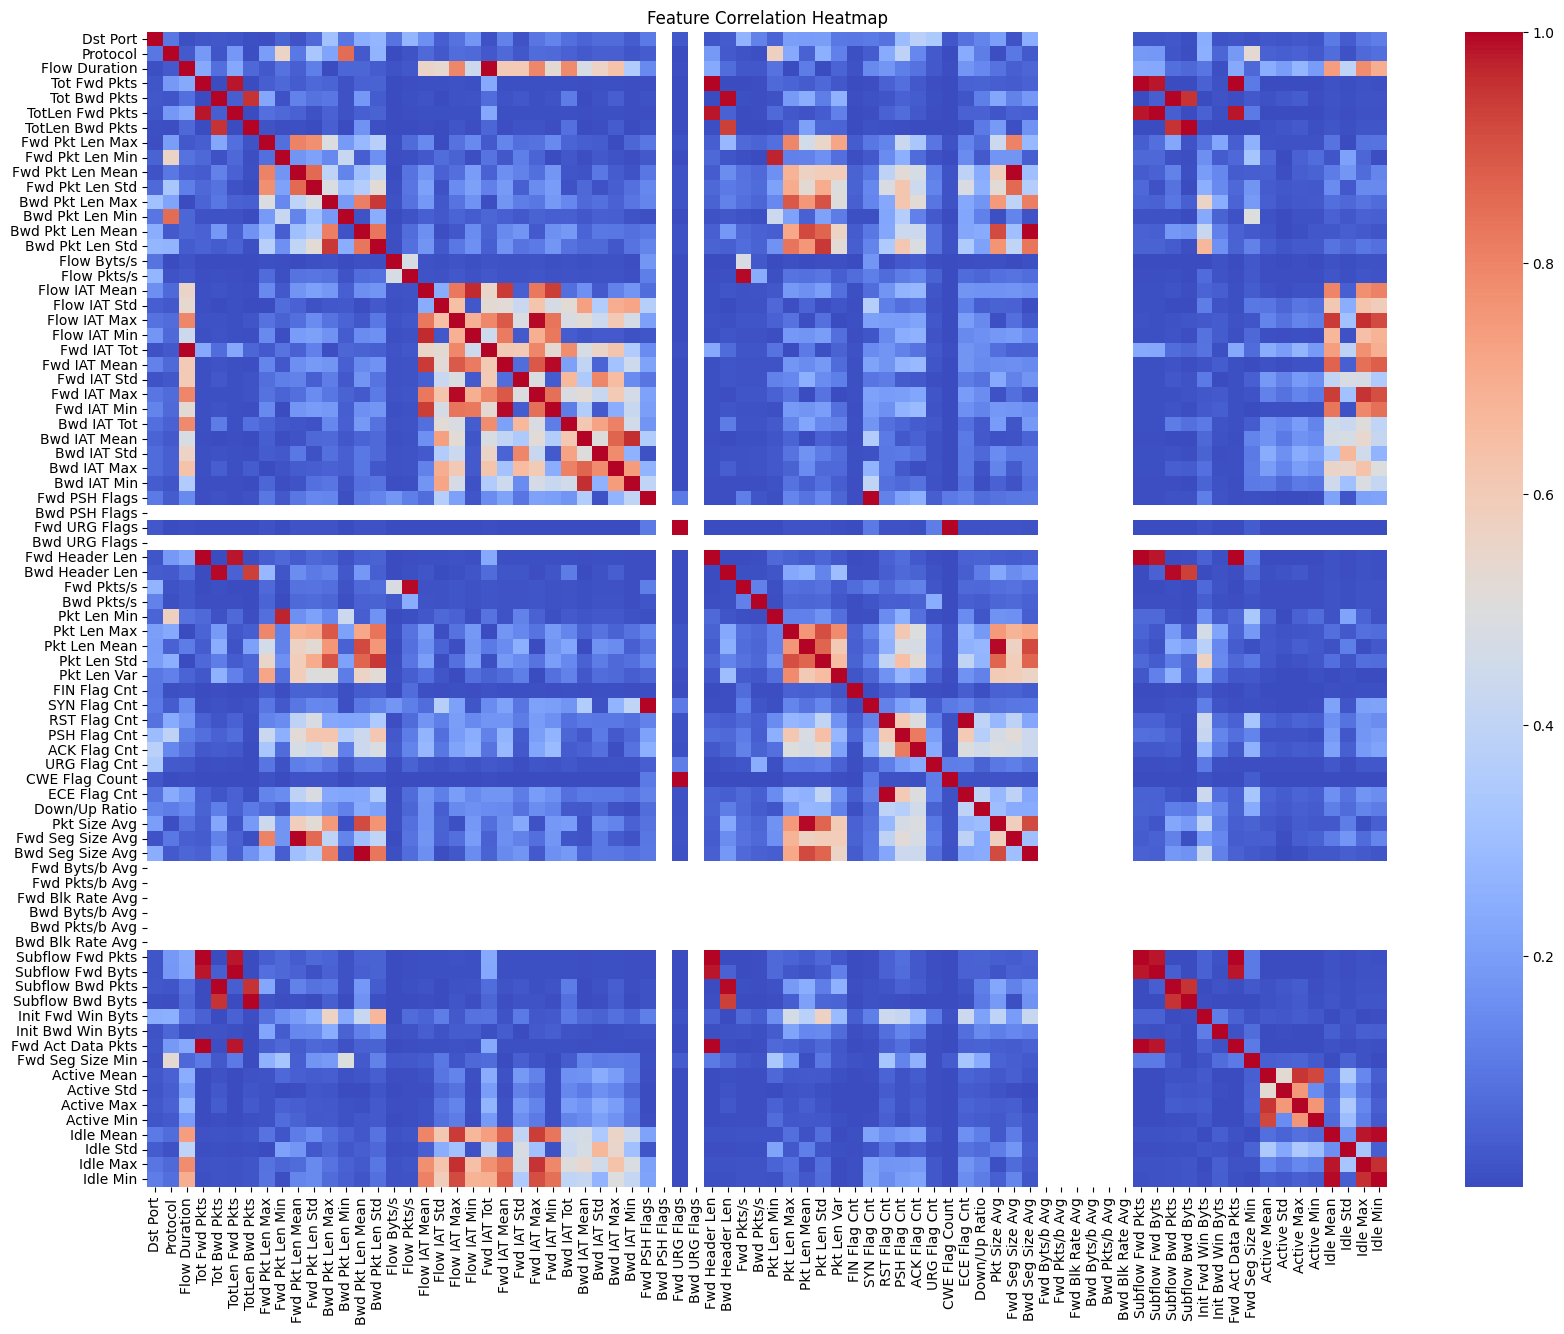

In [202]:
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [203]:
# 3. Automated Feature Drop
# Find features with correlation > 0.95 (Redundant features)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

In [204]:
print(f"\nSuggested to drop {len(to_drop)} redundant features:")
print(to_drop)


Suggested to drop 24 redundant features:
['TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Min', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Pkt Len Min', 'SYN Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts', 'Fwd Act Data Pkts', 'Idle Max', 'Idle Min']


In [205]:
# 4. Drop them from your main balanced dataset
data_final = data_balanced.drop(columns=to_drop)
print(f"\nFinal Feature Count: {len(data_final.columns) - 1}") # -1 for the Label


Final Feature Count: 54


In [206]:
data_final['Label'].value_counts()

,count
Label,
0,183265
3,179385
1,122613
4,106482
2,67257
5,865


# Devide the Dataset

In [207]:
X = data_final.drop('Label', axis = 1)

In [208]:
y = data_final['Label']

Split the Dataset into train test split

In [209]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.75, random_state=43)

# scale the data

In [210]:
scaller = StandardScaler()

In [211]:
X_train_scale = scaller.fit_transform(X_train)
X_test_scale = scaller.transform(X_test)

# 5. SAVE EVERYTHING FOR YOUR UI
# we will need these files for your Streamlit app later

In [212]:
print("\n--- Setup Complete ---")
print(f"Train Shape: {X_train_scale.shape}")
print(f"Test Shape: {X_test_scale.shape}")


--- Setup Complete ---
Train Shape: (494900, 54)
Test Shape: (164967, 54)


# train the models

In [213]:
model1 = RandomForestClassifier(n_estimators=70,n_jobs=-1)

In [214]:
model1.fit(X_train_scale,y_train)

RandomForestClassifier(n_estimators=70, n_jobs=-1)

In [215]:
model1.score(X_train_scale,y_train)

0.9999393816932713

In [216]:
y_pred1 = model1.predict(X_test_scale)

In [217]:
accuracy_score(y_pred1,y_test)

0.9995877963471482

In [218]:
print(classification_report(y_pred1,y_test, target_names=le.classes_))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     45661
         Bot       1.00      1.00      1.00     30547
 Brute Force       1.00      1.00      1.00     16847
        DDoS       1.00      1.00      1.00     45088
         DoS       1.00      1.00      1.00     26629
  Web Attack       0.88      0.97      0.92       195

    accuracy                           1.00    164967
   macro avg       0.98      1.00      0.99    164967
weighted avg       1.00      1.00      1.00    164967



<Axes: >

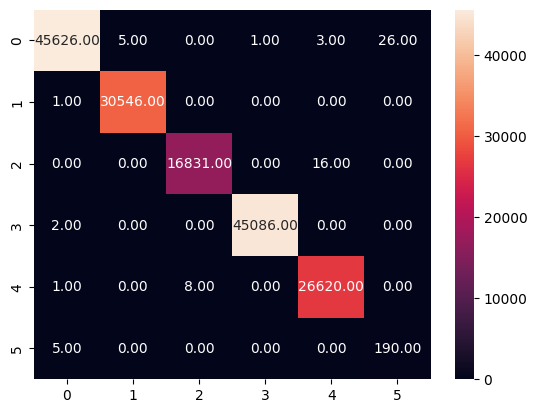

In [219]:
sns.heatmap(confusion_matrix(y_pred1,y_test) , annot = True  , fmt='.2f')

# test another model (Xboost)

In [220]:
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

In [221]:
xgb_model.fit(X_train_scale, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [222]:
xgb_model.score(X_train_scale,y_train)

0.9996686199232168

In [223]:
y_pred_xgb = xgb_model.predict(X_test_scale)

In [224]:
accuracy_score(y_pred_xgb,y_test)

0.9996120436208454

In [225]:
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     45635
         Bot       1.00      1.00      1.00     30551
 Brute Force       1.00      1.00      1.00     16839
        DDoS       1.00      1.00      1.00     45087
         DoS       1.00      1.00      1.00     26639
  Web Attack       1.00      0.82      0.90       216

    accuracy                           1.00    164967
   macro avg       1.00      0.97      0.98    164967
weighted avg       1.00      1.00      1.00    164967



<Axes: >

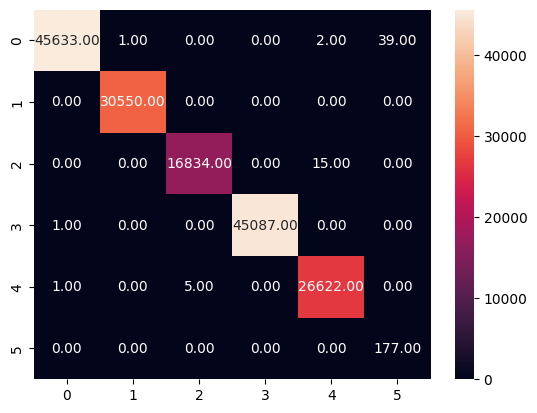

In [226]:
sns.heatmap(confusion_matrix(y_pred_xgb,y_test) , annot = True  , fmt='.2f')

# test model 3, stack model

In [227]:
base_model = [

    ("dt", DecisionTreeClassifier()),
    ("rf",RandomForestClassifier(n_estimators=100 , n_jobs=-1)),
    ("Xgb", XGBClassifier(n_estimators= 100)),
    #('l_svc', LinearSVC(dual=False)),
    ("lr",LogisticRegression())
]

In [228]:
meta_model = RandomForestClassifier(n_estimators=40,n_jobs=-1)

In [229]:
stk_model = StackingClassifier(estimators=base_model , final_estimator=meta_model,n_jobs=-1,cv=3,verbose=True)

In [230]:
stk_model.fit(X_train_scale,y_train)

StackingClassifier(cv=3,
                   estimators=[('dt', DecisionTreeClassifier()),
                               ('rf', RandomForestClassifier(n_jobs=-1)),
                               ('Xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None,
                                              feature_w...
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=100, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('lr', LogisticRegression())],
                   final_estimator=RandomForestClassifier(n_estimators=40,
                                                          n_jobs=-1),
                   n_jobs=-1, verbose=True)

In [231]:
stk_model.score(X_train_scale,y_train)

0.9998989694887856

In [232]:
y_pred_stk = stk_model.predict(X_test_scale)

In [233]:
accuracy_score(y_pred_stk,y_test)

0.9997635890814527

In [234]:
print(classification_report(y_test, y_pred_stk, target_names=le.classes_))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     45635
         Bot       1.00      1.00      1.00     30551
 Brute Force       1.00      1.00      1.00     16839
        DDoS       1.00      1.00      1.00     45087
         DoS       1.00      1.00      1.00     26639
  Web Attack       0.98      0.89      0.93       216

    accuracy                           1.00    164967
   macro avg       1.00      0.98      0.99    164967
weighted avg       1.00      1.00      1.00    164967



<Axes: >

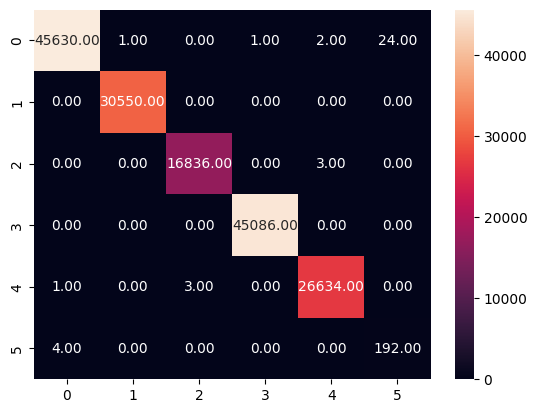

In [235]:
sns.heatmap(confusion_matrix(y_pred_stk,y_test) , annot = True  , fmt='.2f')

# all the model performing well, but for deployment purpose we need speed for prediction, so we go for RandomForest model.

# =====================================================================================
# STAGE: MODEL OPTIMIZATION FOR REAL-TIME DEPLOYMENT
#
# WHAT:
# We are identifying the Top 10 most impactful features, subsetting the data,
# re-performing a Train-Test split, fitting a new Scaler, and retraining the model.
#
# WHY:
# 1. USER EXPERIENCE (UI): Users cannot manually input 51 or 80 features. Reducing
#    inputs to the top 10 makes the Streamlit interface practical and easy to use.
# 2. REDUCING NOISE: By keeping only high-importance features, we remove 'feature
#    clutter' that can sometimes confuse a model, leading to a more robust detector.
# 3. LATENCY & SPEED: A 10-feature model loads faster and makes predictions
#    instantly, which is critical for real-time Network Intrusion Detection (NIDS).
# 4. PIPELINE ALIGNMENT: The Scaler must match the feature count. Since the UI will
#    only provide 10 values, we need a Scaler fitted on those specific 10 features
#    to prevent dimension mismatch errors during deployment.
# =====================================================================================

1. IDENTIFY TOP 10 FEATURES.

We use 'model1' (your Random Forest) to get the rankings

In [236]:

importances = model1.feature_importances_
feature_names = X.columns

In [237]:
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
top_10_features = feature_df.sort_values(by='Importance', ascending=False).head(10)['Feature'].tolist()

In [238]:
print("--- TOP 10 FEATURES FOR UI ---")
for i, feat in enumerate(top_10_features, 1):
    print(f"{i}. {feat}")

--- TOP 10 FEATURES FOR UI ---
1. Fwd Seg Size Min
2. Dst Port
3. Init Fwd Win Byts
4. RST Flag Cnt
5. Tot Bwd Pkts
6. Pkt Len Var
7. Fwd IAT Mean
8. Bwd Pkts/s
9. Pkt Len Std
10. Flow Byts/s


We creating a new dataset with ONLY these 10 columns

In [239]:
X_top10 = X[top_10_features]

In [240]:
X_top10.head()

,Fwd Seg Size Min,Dst Port,Init Fwd Win Byts,RST Flag Cnt,Tot Bwd Pkts,Pkt Len Var,Fwd IAT Mean,Bwd Pkts/s,Pkt Len Std,Flow Byts/s
0,20,443,254,0,0,0.000000,513.0,0.000000,0.000000,0.000000e+00
1,32,35174,219,0,5,90150.046875,1774520.0,0.938966,300.249969,2.317369e+02
2,20,51249,292,0,0,320.333344,1.0,0.000000,17.897858,3.100000e+07
3,8,53,-1,0,1,2352.000000,0.0,867.302673,48.497421,1.370338e+05
4,20,52005,288,0,1,0.000000,0.0,21739.130859,0.000000,0.000000e+00


RE-SPLIT DATA

In [241]:
X_tr, X_te, y_tr, y_te = train_test_split(X_top10,y, train_size=0.75, random_state = 50)

re-scale the data

In [242]:
scaler = StandardScaler()

In [243]:
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

RETRAIN THE FINAL UI MODEL

In [244]:
final_model = RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [245]:
final_model.fit(X_tr_scaled, y_tr)

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [246]:
final_model.score(X_tr_scaled, y_tr)

0.999761567993534

In [247]:
y_pred_final = final_model.predict(X_te_scaled)

In [248]:
accuracy_score(y_pred_final,y_te)

0.9992240872416908

In [249]:
print(classification_report(y_te, y_pred_final, target_names=le.classes_))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     46190
         Bot       1.00      1.00      1.00     30597
 Brute Force       1.00      1.00      1.00     16737
        DDoS       1.00      1.00      1.00     44729
         DoS       1.00      1.00      1.00     26523
  Web Attack       0.88      0.88      0.88       191

    accuracy                           1.00    164967
   macro avg       0.98      0.98      0.98    164967
weighted avg       1.00      1.00      1.00    164967



<Axes: >

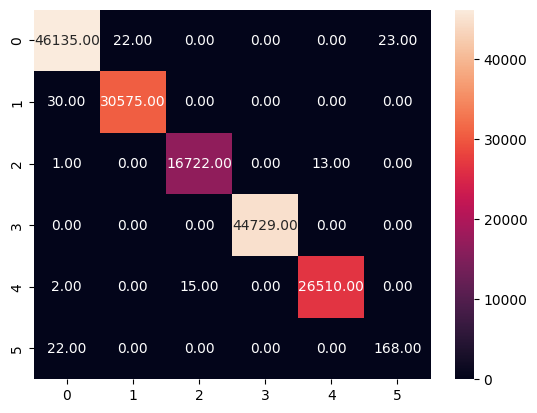

In [250]:
sns.heatmap(confusion_matrix(y_pred_final,y_te) , annot = True  , fmt='.2f')

In [251]:
data_balanced.head()

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,513,2,0,0,0.0,0,0,0.00,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,35174,6,5325005,4,5,935,299.0,935,0,233.75,...,32,0.0,0.0,0.0,0.0,5299159.0,0.0,5299159.0,5299159.0,0
2,51249,6,1,2,0,31,0.0,31,0,15.50,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,53,17,1153,1,1,37,121.0,37,37,37.00,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,52005,6,46,1,1,0,0.0,0,0,0.00,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [252]:
hybrid_features = [
    'Init Fwd Win Byts', 'Dst Port', 'Fwd Seg Size Min',
    'Bwd Pkt Len Std', 'Tot Bwd Pkts', 'Bwd Pkts/s', 'Bwd Pkt Len Max', # Global
    'Pkt Size Avg', 'Fwd Header Len', 'Pkt Len Max' # Payload Specialists
]

In [253]:
X_hybrid = data_balanced.drop('Label',axis = 1)

In [254]:
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hybrid, y, test_size=0.2, stratify=y, random_state=43
)

In [255]:
scaler_h = StandardScaler()
X_train_h_scaled = scaler_h.fit_transform(X_train_h)
X_test_h_scaled = scaler_h.transform(X_test_h)

In [256]:
final_nids_model = RandomForestClassifier(
    n_estimators=550,
    n_jobs=-1,
    random_state=42
)

In [257]:
print("Training the Hybrid NIDS Model...")
final_nids_model.fit(X_train_h_scaled, y_train_h)

Training the Hybrid NIDS Model...


RandomForestClassifier(n_estimators=550, n_jobs=-1, random_state=42)

In [258]:
final_nids_model.score(X_train_h_scaled, y_train_h)

0.9999431703015573

In [259]:
y_pred_h = final_nids_model.predict(X_test_h_scaled)
print("\n--- HYBRID MODEL PERFORMANCE ---")
print(classification_report(y_test_h, y_pred_h, target_names=le.classes_))


--- HYBRID MODEL PERFORMANCE ---
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     36653
         Bot       1.00      1.00      1.00     24523
 Brute Force       1.00      1.00      1.00     13451
        DDoS       1.00      1.00      1.00     35877
         DoS       1.00      1.00      1.00     21297
  Web Attack       0.95      0.83      0.89       173

    accuracy                           1.00    131974
   macro avg       0.99      0.97      0.98    131974
weighted avg       1.00      1.00      1.00    131974



<Axes: >

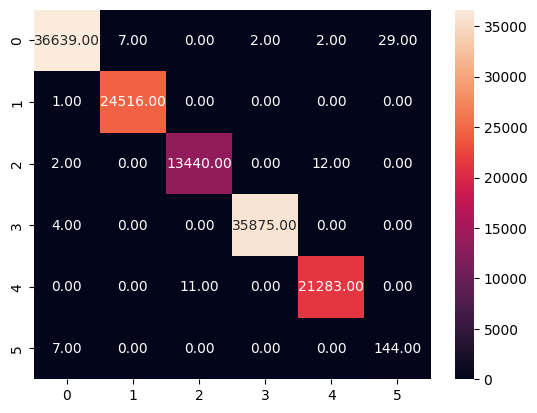

In [260]:
sns.heatmap(confusion_matrix(y_pred_h,y_test_h) , annot = True  , fmt='.2f')

In [261]:
importances = final_nids_model.feature_importances_

In [262]:
feature_names = X.columns

In [264]:
# 1. Get the raw importance scores
importances = final_nids_model.feature_importances_

# 2. Get the feature names from the data used for the 0.83 recall run
# We must ensure this list is exactly the same length as the importances
# If you used 'X_hybrid' or the full balanced dataframe, use that here:
current_features = X_hybrid.columns if 'X_hybrid' in locals() else X.columns

# 3. Create the DataFrame safely
if len(current_features) == len(importances):
    feature_df = pd.DataFrame({'Feature': current_features, 'Importance': importances})
    top_15_features = feature_df.sort_values(by='Importance', ascending=False).head(15)['Feature'].tolist()

    print("--- TOP 15 FEATURES FOR UI ---")
    for i, feat in enumerate(top_15_features, 1):
        print(f"{i}. {feat}")
else:
    print(f"Mismatch! Model expects {len(importances)} features, but your list has {len(current_features)}.")
    print("Try using: feature_names = data_balanced.drop(columns=['Label', 'Grouped_Label']).columns")

--- TOP 15 FEATURES FOR UI ---
1. Init Fwd Win Byts
2. Fwd Seg Size Min
3. Dst Port
4. RST Flag Cnt
5. Fwd Header Len
6. ECE Flag Cnt
7. Bwd Header Len
8. Bwd Pkts/s
9. Flow Byts/s
10. Fwd IAT Tot
11. Pkt Len Var
12. Bwd Pkt Len Std
13. Subflow Bwd Pkts
14. Subflow Bwd Byts
15. Fwd IAT Mean


In [265]:
final_ui_features = [
    'Init Fwd Win Byts', 'Fwd Seg Size Min', 'Dst Port', 'RST Flag Cnt',
    'Fwd Header Len', 'ECE Flag Cnt', 'Bwd Header Len', 'Bwd Pkts/s',
    'Flow Byts/s', 'Fwd IAT Tot', 'Pkt Len Var', 'Bwd Pkt Len Std',
    'Subflow Bwd Pkts', 'Subflow Bwd Byts', 'Fwd IAT Mean'
]

# 2. Subset the data
X_final_ui = data_balanced[final_ui_features]
y_final = y

In [267]:
X_train_ui, X_test_ui, y_train_ui, y_test_ui = train_test_split(X_final_ui, y_final, train_size=0.75 ,random_state=42)

In [268]:
scaler_ui = StandardScaler()
X_train_scaled_ui = scaler_ui.fit_transform(X_train_ui)
X_test_scaled_ui = scaler_ui.transform(X_test_ui)

In [299]:
ui_model = RandomForestClassifier(
    n_estimators=400,
    n_jobs=-1,
    random_state=42
)

In [300]:
ui_model.fit(X_train_scaled_ui, y_train_ui)

RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=42)

In [301]:
ui_model.score(X_train_scaled_ui, y_train_ui)

0.999824206910487

In [302]:
y_prd = ui_model.predict(X_test_scaled_ui)

In [303]:
print(classification_report(y_test_ui,y_prd , target_names=le.classes_))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     45834
         Bot       1.00      1.00      1.00     30647
 Brute Force       1.00      1.00      1.00     16934
        DDoS       1.00      1.00      1.00     44844
         DoS       1.00      1.00      1.00     26485
  Web Attack       0.89      0.86      0.88       223

    accuracy                           1.00    164967
   macro avg       0.98      0.98      0.98    164967
weighted avg       1.00      1.00      1.00    164967



<Axes: >

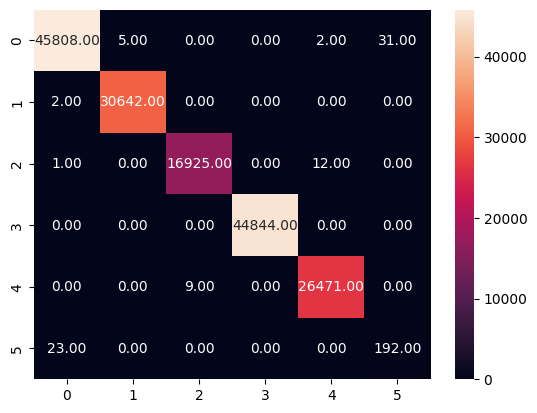

In [304]:
sns.heatmap(confusion_matrix(y_prd,y_test_ui) , annot = True  , fmt='.2f')

In [276]:
xgb_model2 = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

In [277]:
xgb_model2.fit(X_train_scaled_ui, y_train_ui)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [278]:
xgb_model2.score(X_train_scaled_ui, y_train_ui)

0.9995877955142453

In [279]:
y_pp = xgb_model2.predict(X_test_scaled_ui)

In [280]:
print(classification_report(y_test_ui,y_pp , target_names=le.classes_))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     45834
         Bot       1.00      1.00      1.00     30647
 Brute Force       1.00      1.00      1.00     16934
        DDoS       1.00      1.00      1.00     44844
         DoS       1.00      1.00      1.00     26485
  Web Attack       0.99      0.82      0.90       223

    accuracy                           1.00    164967
   macro avg       1.00      0.97      0.98    164967
weighted avg       1.00      1.00      1.00    164967



<Axes: >

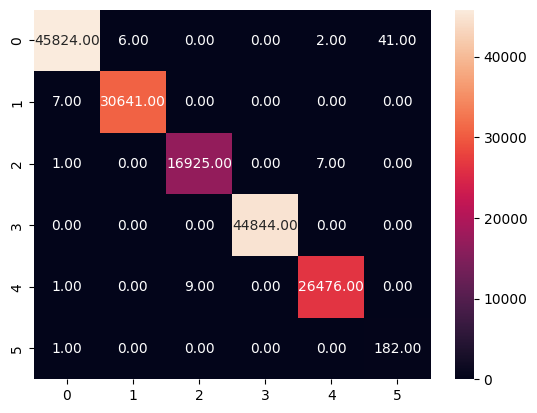

In [290]:
sns.heatmap(confusion_matrix(y_pp,y_test_ui) , annot = True  , fmt='.2f')

Random Forest woriking good

In [305]:
# Saving the model (The 'Brain')
joblib.dump(ui_model, 'nids_random_forest.pkl')

['nids_random_forest.pkl']

In [306]:
from google.colab import files

In [307]:
files.download('nids_random_forest.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [309]:
# Saving the scaler (The 'Filter' - MUST be the one fitted on 15 features)
joblib.dump(scaler_ui, 'nids_scaler.pkl')

['nids_scaler.pkl']

In [310]:
files.download('nids_scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [311]:
# 1. THE FINAL FEATURE LIST (Matches your 0.87 Recall run)
final_15_features = [
    'Init Fwd Win Byts', 'Fwd Seg Size Min', 'Dst Port', 'RST Flag Cnt',
    'Fwd Header Len', 'ECE Flag Cnt', 'Bwd Header Len', 'Bwd Pkts/s',
    'Flow Byts/s', 'Fwd IAT Tot', 'Pkt Len Var', 'Bwd Pkt Len Std',
    'Subflow Bwd Pkts', 'Subflow Bwd Byts', 'Fwd IAT Mean'
]

In [312]:
joblib.dump(final_15_features, 'nids_features.pkl')

['nids_features.pkl']

In [313]:
files.download('nids_features.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [314]:
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [315]:
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [316]:
joblib.dump(le.classes_, 'attack_classes.pkl')

['attack_classes.pkl']

In [317]:
files.download('attack_classes.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>